# HW3 -- MAKE A COPY BEFORE YOU BEGIN

In [1]:
!pip install --upgrade "git+https://github.com/RyanMarcus/penngrader2.git@8a34a2c"
!pip install polars_ds



  Cloning https://github.com/RyanMarcus/penngrader2.git (to revision 8a34a2c) to /private/var/folders/l8/fvvljd5s18dby2czc2wrwhtm0000gn/T/pip-req-build-lhdk0mt9
  Running command git clone --filter=blob:none --quiet https://github.com/RyanMarcus/penngrader2.git /private/var/folders/l8/fvvljd5s18dby2czc2wrwhtm0000gn/T/pip-req-build-lhdk0mt9
  Did not find branch or tag '8a34a2c', assuming revision or ref.
  Running command git checkout -q 8a34a2c
  Resolved https://github.com/RyanMarcus/penngrader2.git to commit 8a34a2c
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


# Setup

Change the `penngrader2.login` call below to your student ID. Do not change anything else in the below cell.

In [2]:
import penngrader2
import numpy as np
import polars as pl
import polars_ds as pds

penngrader2.configure("https://pg2.rmarcus.info/", api_key="de61f526fe91fa3327ba4c61041f6bf68a669ff3b3d881747ed66984f1cabbdd")
penngrader2.login(22249256)


# Part 1: Computing $\pi$

Let's compute $\pi$ using the power of computation. Imagine a unit square (a 1x1 square) with a circle of radius 0.5 inscribed inside.

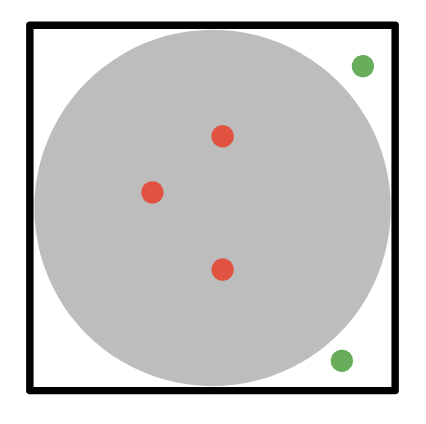

Suppose we randomly sample some points from inside the unit square, as shown above. Some of the points will land inside the circle (red), while others will be inside the square but outside the circle (green).

We know that the area of the circle divided by the area of the square is related to $\pi$ by:

$\frac{\mbox{circle area}}{\mbox{square area}} = \frac{\pi r^2}{1}$

Solving for $\pi$ gives:

$\pi = 4 \frac{\mbox{circle area}}{\mbox{square area}}$

We can compute circle area/square area using a simple Monte Carlo simulation. Sampling a random point uniformly inside the square is easy, we just pick a random value between 0 and 1 twice. Then, we can see if that random point is inside the circle. The (num points inside circle / total points) is an approximation of circle area/square area.

## 1.1 Iterative simulation (5 points)

Here's a simple Python program that computes $\pi$ using the technique above. Unfortunately, it is not very accurate right now. Adjust the iteration count to 10 million (10_000_000) and run the code. Observe the accuracy of the answer and the time spent on the calculation.

In [3]:
%%time
import random
random.seed(42)

pts_in_circle = 0
pts_in_square = 0
for _ in range(10_000_000):
  x = random.random() - 0.5
  y = random.random() - 0.5

  if x**2 + y**2 <= 0.25:
    pts_in_circle += 1
  pts_in_square += 1

print(4.0 * pts_in_circle / pts_in_square)

3.1421736
CPU times: user 2.5 s, sys: 16.2 ms, total: 2.51 s
Wall time: 2.53 s


In [4]:
# WARNING: YOU MUST RUN THIS CELL IMMEDIATELY AFTER RUNNING THE CELL ABOVE. If
# you run some cell in between, you will get a nonsense grade.

src = In[len(In) - 2]
penngrader2.submit("hw3", "problem1_1", src)

[queued] Queued for grading (position 1)
[started] Grading started
[succeeded] Grading completed
✅ Correct. Score: 5/5. Correct


## 1.2 Vectorized simulation (15 points)

Let's rewrite the above simulation using vectorization with `numpy`. Your code should not use any Python iteration constructs (such as `for`, `while`, `filter`, `map`, etc.).

Hint: you can use `np.random.rand(10_000_000)` to generate 10M random values between 0 and 1.

Use `%%time` to measure how long your simulation takes to run. Print out your estimate of $\pi$ at the end.

In [5]:
%%time

# TODO
np.random.seed(42)
x = np.random.rand(10_000_000) - 0.5
y = np.random.rand(10_000_000) - 0.5
pi_est = float(4 * np.mean(x**2 + y**2 <= 0.25))


print(pi_est)

3.1417068
CPU times: user 119 ms, sys: 37.6 ms, total: 156 ms
Wall time: 178 ms


In [6]:
# WARNING: YOU MUST RUN THIS CELL IMMEDIATELY AFTER RUNNING THE CELL ABOVE. If
# you run some cell in between, you will get a nonsense grade.

src = In[len(In) - 2]
penngrader2.submit("hw3", "problem1_2", src)

Rate limited. Waiting 14s before retrying submission...
[queued] Queued for grading (position 1)
[started] Grading started
[progress] Prepared grading assistant call
[progress] Grading assitant response is parsed
[succeeded] Grading completed
✅ Correct. Score: 15/15. 



# Part 2: Property data

Let's analyze some real estate data from California. We'll fetch the data in [Parquet format](https://www.databricks.com/blog/what-is-parquet) and load it into a Pandas dataframe.

In [7]:
!wget -nc https://upenn.ferric.systems/cis5450/ca_housing.parquet

File ‘ca_housing.parquet’ already there; not retrieving.



Next, we load it in Pandas:

In [8]:
import pandas as pd
df = pd.read_parquet("ca_housing.parquet")
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,$83.3k,41.0,6.984127,1.023810,0.3k,2.555556,37.88,-122.23,$452.6k
1,$83k,21.0,6.238137,0.971880,2.4k,2.109842,37.86,-122.22,$358.5k
2,$72.6k,52.0,8.288136,1.073446,0.5k,2.802260,37.85,-122.24,$352.1k
3,$56.4k,52.0,5.817352,1.073059,0.6k,2.547945,37.85,-122.25,$341.3k
4,$38.5k,52.0,6.281853,1.081081,0.6k,2.181467,37.85,-122.25,$342.2k
...,...,...,...,...,...,...,...,...,...
20635,$15.6k,25.0,5.045455,1.133333,0.8k,2.560606,39.48,-121.09,$78.1k
20636,$25.6k,18.0,6.114035,1.315789,0.4k,3.122807,39.49,-121.21,$77.1k
20637,$17k,17.0,5.205543,1.120092,1k,2.325635,39.43,-121.22,$92.3k
20638,$18.7k,18.0,5.329513,1.171920,0.7k,2.123209,39.43,-121.32,$84.7k


## 2.1 Cleaning housing data (5 points)

The housing data has these columns:

* `MedInc`, the median household income in a population block
* `HouseAge`, the median age of a home in a population block
* `AveRooms`, the average number of rooms in a home in a population block
* `AveBedrms`, the average number of bedrooms in a home in the population block
* `Population` , the size of the population block (number of people)
* `AveOccup`, the average number of people in a home in a population block
* `Latitude` and `Longitude` of the population block's center
* `MedHouseVal`, the median home value in the population block

Let's clean the data -- first, transform `MedInc`, `MedHouseVal`, and `Population` into integer columns with the correct values. Afterwards, sort the dataframe by `MedInc` ascending, breaking ties with `HouseAge` ascending, and reset the index.

Save your cleaned dataframe as `ca_housing_clean`.

In [9]:
ca_housing_clean = df.copy()

# TODO
# Values such as "$83.3k" and "0.3k" are expressed in thousands.
for column in ["MedInc", "MedHouseVal", "Population"]:
    ca_housing_clean[column] = (
        ca_housing_clean[column].str.replace("$", "", regex=False)
        .str.replace("k", "", regex=False).astype(float)
        .mul(1000).round().astype("int64")
    )
ca_housing_clean = ca_housing_clean.sort_values(
    ["MedInc", "HouseAge"], kind="stable"
).reset_index(drop=True)


ca_housing_clean

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,5000,10.0,6.740000,2.040000,100,2.160000,34.69,-116.90,55000
1,5000,15.0,11.596491,2.561404,100,2.298246,40.43,-123.32,56700
2,5000,16.0,21.631579,6.000000,0,1.368421,39.42,-122.89,73500
3,5000,23.0,6.054545,1.672727,200,3.600000,36.09,-119.99,100000
4,5000,28.0,7.677419,1.870968,100,4.580645,34.15,-118.08,500000
...,...,...,...,...,...,...,...,...,...
20635,150000,52.0,8.710145,1.028986,400,2.956522,34.07,-118.41,500000
20636,150000,52.0,8.000000,0.997333,1100,3.048000,34.04,-118.50,500000
20637,150000,52.0,7.994475,1.027624,500,2.668508,37.79,-122.44,500000
20638,150000,52.0,8.000000,1.000000,0,13.000000,37.79,-122.50,500000


In [10]:
penngrader2.submit("hw3", "problem2_1", ca_housing_clean.head().to_json())

Rate limited. Waiting 11s before retrying submission...
[queued] Queued for grading (position 1)
[started] Grading started
[succeeded] Grading completed
✅ Correct. Score: 5/5. Correct answer.


## 2.2 Plot a panel (5 points)

Let's plot a panel of plots from this dataset to understand some of the basic relationships. Using `matplotlib`, create a single figure with 3 scatterplots with grid lines laid out in a row. Make the points transparent (alpha=0.25) to help visualize the mass.

Plot:

* MedInc vs MedHouseVal
* Population vs AveOccup
* HouseAge vs MedHouseVal

Once you see the plots, look for any data oddities in the MedHouseVal or HouseAge columns. Remove them from your dataset. For example, if a particular value is clipped at a certain maximum, remove values at that maximum. Remove any rows where `AveOccup` is greater than or equal to the 99.9th percentile of the original cleaned data (after the previous cleaning step, but before this one).

Afterwards, replot your fixed data and save your plot as "plot.jpg".

Call the cleaned data frame (with values dropped) `ca_housing_clean` again.

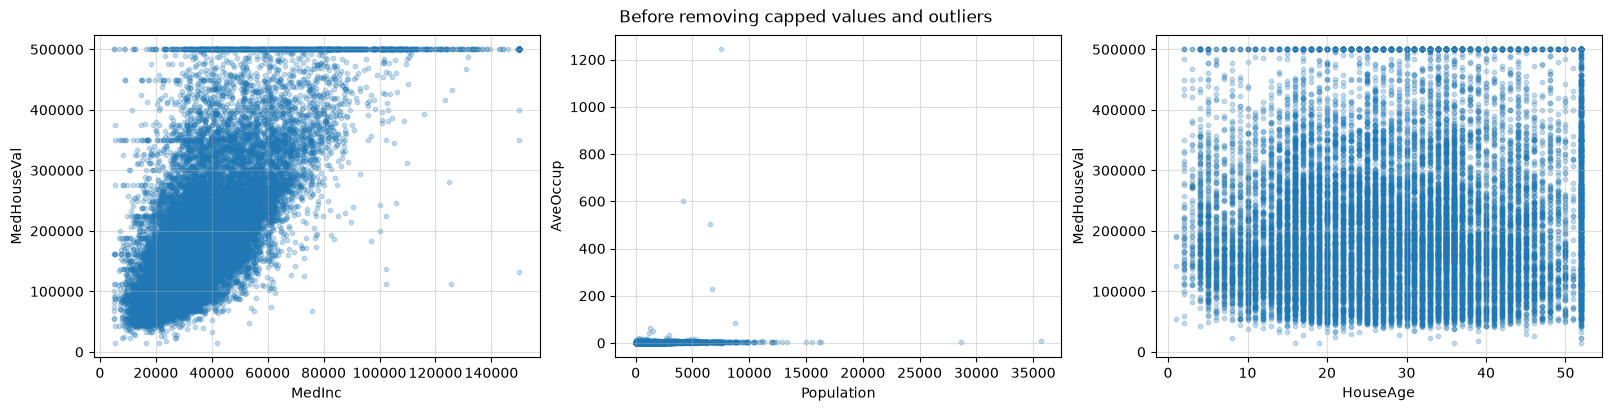

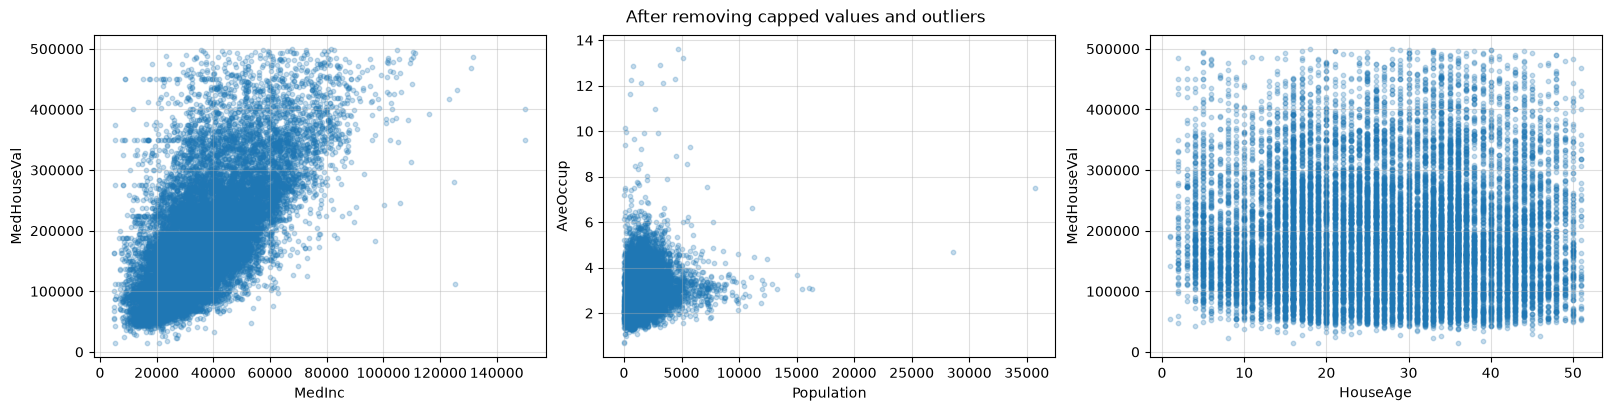

In [11]:
from matplotlib import pyplot as plt

# TODO
def plot_housing_panel(data, title):
    figure, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)
    pairs = [("MedInc", "MedHouseVal"), ("Population", "AveOccup"),
             ("HouseAge", "MedHouseVal")]
    for ax, (predictor, response) in zip(axes, pairs):
        ax.scatter(data[predictor], data[response], alpha=0.25, s=10)
        ax.set_xlabel(predictor)
        ax.set_ylabel(response)
        ax.grid(True, alpha=0.4)
    figure.suptitle(title)
    return figure

original_fig = plot_housing_panel(ca_housing_clean, "Before removing capped values and outliers")
plt.show()
# Compute all thresholds before filtering any rows.
occupancy_cutoff = ca_housing_clean["AveOccup"].quantile(0.999)
house_value_cap = ca_housing_clean["MedHouseVal"].max()
house_age_cap = ca_housing_clean["HouseAge"].max()
ca_housing_clean = ca_housing_clean.loc[
    (ca_housing_clean["MedHouseVal"] < house_value_cap)
    & (ca_housing_clean["HouseAge"] < house_age_cap)
    & (ca_housing_clean["AveOccup"] < occupancy_cutoff)
].copy()
fig = plot_housing_panel(ca_housing_clean, "After removing capped values and outliers")
plt.show()


fig.savefig("plot.jpg")

In [12]:
import base64
with open('plot.jpg', 'rb') as image_file:
    img = base64.b64encode(image_file.read()).decode('utf-8')

penngrader2.submit("hw3", "problem2_2", {"img": img, "rc": len(ca_housing_clean)})

Rate limited. Waiting 11s before retrying submission...
[queued] Queued for grading (position 1)
[started] Grading started
[progress] Fetched ground truth
[progress] Prepared grading assistant call
[progress] Grading assitant response is parsed
[succeeded] Grading completed
✅ Correct. Score: 5/5. 



## 2.3 SLR (5 points)

Let's use simple linear regression to understand a few relationships. First, use simple linear regression to measure the average increase in our response variables when there is a unit increase in our input variables. Compute this value for:

* A 1 dollar increase in median income vs. median home value (`medinc_to_medval`)
* A 1 person increase in population vs. average occupancy (`pop_to_occ`)
* A 1 year increase in median home age vs. median household value (`medage_to_medval`)

Make sure to extract the coefficient, don't just return the whole coefficient array.

In [13]:
from sklearn.linear_model import LinearRegression

In [14]:
# TODO
medinc_to_medval = float(LinearRegression().fit(
    ca_housing_clean[["MedInc"]], ca_housing_clean["MedHouseVal"]
).coef_[0])
pop_to_occ = float(LinearRegression().fit(
    ca_housing_clean[["Population"]], ca_housing_clean["AveOccup"]
).coef_[0])
medage_to_medval = float(LinearRegression().fit(
    ca_housing_clean[["HouseAge"]], ca_housing_clean["MedHouseVal"]
).coef_[0])


(medinc_to_medval, pop_to_occ, medage_to_medval)

(4.043598003844281, 0.00011924492154395105, 115.65026641440735)

In [15]:
penngrader2.submit("hw3", "problem2_3", [medinc_to_medval, pop_to_occ, medage_to_medval])

Rate limited. Waiting 4s before retrying submission...
[queued] Queued for grading (position 1)
[started] Grading started
[succeeded] Grading completed
✅ Correct. Score: 5/5.


## 2.4 Dealing with geographic data (15 points)

Here's a plot of our cleaned dataset's longitude vs. latitude:

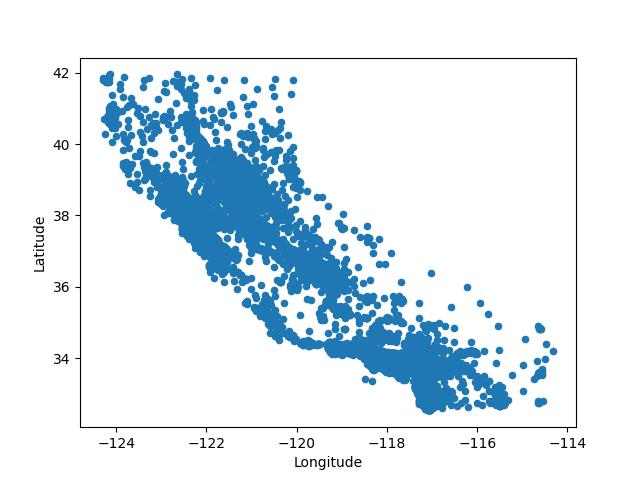

Notice that the data is in the shape of California (slightly skewed due to our flat projection). The longitude and latitude alone don't really make sense as features by themselves, because a longitude of -118 is coastal in San Diego, but inland in Northern California (possibly in Nevada).

Let's invent a new feature -- `is_coastal` -- that will be `True` if a population block is close to the coast, and `False` otherwise.

We'll use a simple algorithm to find the coastline. Split the data into 100 latitude bins of equal height (see `pd.cut` and `np.linspace`). For each bin, find the western-most point (lowest longitude of the bin with mean latitude of the points in the bin). Call this set of 100 points the "coastline set." Then, for every point in the dataset, compute its distance to the nearest point in the coastline set. If the point is within 10 miles of a coastal point, call it coastal. Otherwise, consider it non-coastal.

You can compare each housing block to a set of points by taking the cross product.

Combine your new feature with `ca_housing_clean`.

You may find it helpful to plot the coastal and non-coastal cities on a scatter plot.

In [16]:
# example of computing distance between two points on Earth (if it's too slow
# to use with .apply, you might have to vectorize it!)
def haversine_miles(pt1, pt2):
  lat1, lon1 = pt1
  lat2, lon2 = pt2

  lat1 = np.radians(lat1)
  lon1 = np.radians(lon1)
  lat2 = np.radians(lat2)
  lon2 = np.radians(lon2)

  dlat = lat2 - lat1
  dlon = lon2 - lon1
  a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
  c = 2 * np.arcsin(np.sqrt(a))

  earth_radius_miles = 3958.8
  return earth_radius_miles * c

p1 = (37.7749, -122.4194)   # San Francisco
p2 = (34.0522, -118.2437)   # Los Angeles

haversine_miles(p1, p2)


np.float64(347.4252928066673)

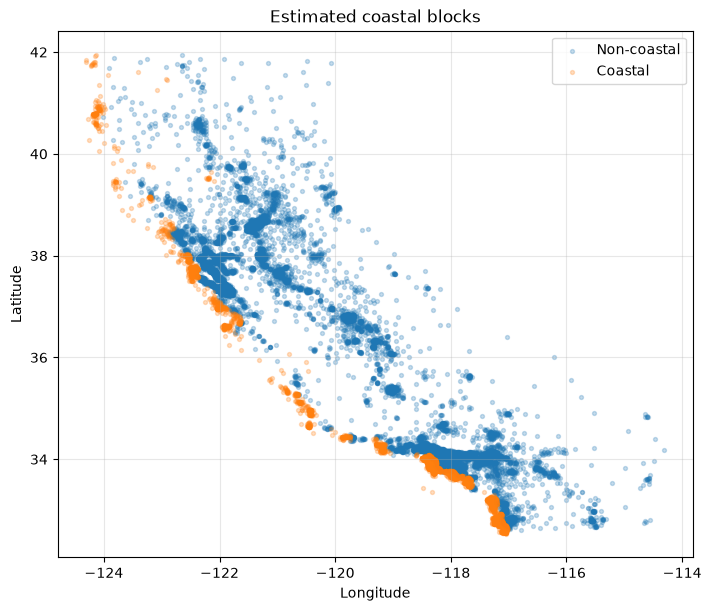

In [17]:
# TODO
latitude_edges = np.linspace(ca_housing_clean["Latitude"].min(),
                             ca_housing_clean["Latitude"].max(), 101)
latitude_bins = pd.cut(ca_housing_clean["Latitude"], bins=latitude_edges,
                       include_lowest=True)
coastline = ca_housing_clean.groupby(latitude_bins, observed=True).agg(
    Latitude=("Latitude", "mean"), Longitude=("Longitude", "min")
).reset_index(drop=True)
# Broadcasting forms the block-by-coastline cross product without Python loops.
coast_distances = haversine_miles(
    (ca_housing_clean["Latitude"].to_numpy()[:, None],
     ca_housing_clean["Longitude"].to_numpy()[:, None]),
    (coastline["Latitude"].to_numpy()[None, :],
     coastline["Longitude"].to_numpy()[None, :])
)
ca_housing_clean["is_coastal"] = coast_distances.min(axis=1) <= 10
fig_coast, ax_coast = plt.subplots(figsize=(7, 6), constrained_layout=True)
for coastal, label in [(False, "Non-coastal"), (True, "Coastal")]:
    blocks = ca_housing_clean.loc[ca_housing_clean["is_coastal"] == coastal]
    ax_coast.scatter(blocks["Longitude"], blocks["Latitude"],
                    s=8, alpha=0.25, label=label)
ax_coast.set(xlabel="Longitude", ylabel="Latitude", title="Estimated coastal blocks")
ax_coast.legend()
ax_coast.grid(alpha=0.3)
plt.show()


In [18]:
penngrader2.submit("hw3", "problem2_4",
                   ca_housing_clean[ca_housing_clean["is_coastal"]].to_json())

Rate limited. Waiting 13s before retrying submission...
[queued] Queued for grading (position 1)
[started] Grading started
[succeeded] Grading completed
✅ Correct. Score: 15/15.


## 2.5 Hypothesis test (10 points)

Let's test the hypothesis that coastal homes have a higher value than non-coastal homes. We'll pick $\alpha = 0.05$.

Write a simulation-based hypothesis test to help answer this question. Assume the `is_coastal` labels are exchangeable in the null world. Run at least 100k iterations.

Once you observe your P-value, fill out the "interpretation" variable with your interpretation and conclusion from this experiment.

In [19]:
df = ca_housing_clean.copy()

# TODO

empirical_p = None

# H0: coastal labels are exchangeable; H1: coastal mean value is higher.
values = df["MedHouseVal"].to_numpy(dtype=float)
coastal_mask = df["is_coastal"].to_numpy(dtype=bool)
n_coastal = int(coastal_mask.sum())
n_noncoastal = len(values) - n_coastal
observed_difference = values[coastal_mask].mean() - values[~coastal_mask].mean()
rng = np.random.default_rng(42)
n_permutations = 100_000
null_differences = np.empty(n_permutations)
total_value = values.sum()
for iteration in range(n_permutations):
    # Permuting values against fixed labels is equivalent to permuting labels.
    shuffled = rng.permutation(values)
    coastal_total = shuffled[:n_coastal].sum()
    null_differences[iteration] = (
        coastal_total / n_coastal - (total_value - coastal_total) / n_noncoastal
    )
extreme_count = int(np.count_nonzero(null_differences >= observed_difference))
# Add-one correction avoids reporting an estimated tail probability of exactly zero.
empirical_p = (extreme_count + 1) / (n_permutations + 1)
print(f"Observed coastal minus non-coastal mean: ${observed_difference:,.2f}")
print(f"Extreme permutations: {extreme_count}/{n_permutations}; p = {empirical_p:.8g}")


Observed coastal minus non-coastal mean: $51,494.68
Extreme permutations: 0/100000; p = 9.9999e-06


In [20]:
# WARNING, only run this cell immediately after you run your simulation.

interpretation = """
Based on my empirical P value of < 1/100k, I reject the null hypothesis.
"""

interpretation = (
    f"The observed coastal minus non-coastal mean home value is "
    f"${observed_difference:,.2f}. Under exchangeable coastal labels, "
    f"{extreme_count} of {n_permutations:,} permutations were at least as large. "
    f"The add-one Monte Carlo P value is {empirical_p:.8g}. "
    + ("At alpha = 0.05, reject the null: coastal blocks have higher mean home values. "
       if empirical_p < 0.05 else
       "At alpha = 0.05, fail to reject the null: insufficient evidence of higher coastal values. ")
    + "This is an association, not proof of causation; other characteristics may confound it. "
      "Zero exceedances, if observed, do not imply that the true P value is zero."
)

src = In[len(In) - 2]
penngrader2.submit("hw3", "problem2_5",
                   {"code": src, "interp": interpretation})

[queued] Queued for grading (position 1)
[started] Grading started
[progress] Prepared grading assistant call
[progress] Grading assitant response is parsed
[succeeded] Grading completed
✅ Correct. Score: 10/10. 



## 2.6 Confidence intervals (5 points)

Now that we've established whether or not being coastal, on its own, indicates a significantly different home value, let's try to measure exactly how much being coastal improves the value of a home *while accounting for the other variables in the dataset*. Your regression should account for:

* `MedInc`, `HouseAge`, `AveRooms`,	`AveBedrms`, `Population`, `AveOccup`, `is_coastal`

To do this, we'll compute confidence intervals on the regression coefficient for the `is_coastal` indicator variable. Do this by bootstrapping: repeatedly take samples of your data with replacement, measure the slope, and then compute an empirical 95% confidence interval. Run 10k iterations.

Save your interval as `ci = (lb, ub)`.

Note: in general, you should run a hypothesis test for the MLR as well, but we'll skip it for now.

In [21]:
# TODO
from time import perf_counter
from threadpoolctl import threadpool_limits

regression_features = ["MedInc", "HouseAge", "AveRooms", "AveBedrms",
                       "Population", "AveOccup", "is_coastal"]

def bootstrap_sklearn(data, iterations=10_000, seed=42):
    rng = np.random.default_rng(seed)
    predictors = data[regression_features].to_numpy(dtype=float)
    response = data["MedHouseVal"].to_numpy(dtype=float)
    coefficients = np.empty(iterations)
    # Limit BLAS to one core for the baseline comparison.
    with threadpool_limits(limits=1):
        for iteration in range(iterations):
            rows = rng.integers(0, len(data), size=len(data))
            model = LinearRegression().fit(predictors[rows], response[rows])
            coefficients[iteration] = model.coef_[regression_features.index("is_coastal")]
    return tuple(float(bound) for bound in np.quantile(coefficients, [0.025, 0.975]))

start_sklearn = perf_counter()
ci = bootstrap_sklearn(ca_housing_clean)
sklearn_seconds = perf_counter() - start_sklearn
print(f"scikit-learn: {sklearn_seconds:.2f} seconds; 95% CI in dollars: {ci}")
# This estimates an adjusted association, not a causal effect of coastal location.


ci


scikit-learn: 22.59 seconds; 95% CI in dollars: (30335.3035320741, 35397.8510651462)


(30335.3035320741, 35397.8510651462)

In [22]:
penngrader2.submit("hw3", "problem2_6", {"lb": ci[0], "ub": ci[1]})

[queued] Queued for grading (position 1)
[started] Grading started
[succeeded] Grading completed
✅ Correct. Score: 5/5.


## 2.7 Speeding up CIs (10 points)

Your free tier Colab environment has two cores, but so far we have only used one. We can use Polars to take advantage of both cores.

Rewrite your CI calculation using Polars. You can use [`pds.lin_reg`](https://polars-ds-extension.readthedocs.io/en/latest/expr_linear.html) to do a linear regression directly in Polars. Make sure to add a bias term, and pay attention to the layout of the coefs. Again, do 10k iterations. Save the result as tuple `ci_pl`.

Measure the time of both functions and compare their speeds. You won't get exactly the same answer as before due to small differences in how scikit-learn and polars_ds computes LR.

In [23]:
pl_df = pl.from_pandas(ca_housing_clean)

In [24]:
# TODO
from time import perf_counter

def bootstrap_polars(data, iterations=10_000, seed=42, batch_size=32):
    rng = np.random.default_rng(seed)
    features = ["MedInc", "HouseAge", "AveRooms", "AveBedrms",
                "Population", "AveOccup", "is_coastal"]
    numeric_data = data.select(features + ["MedHouseVal"]).cast(pl.Float64)
    coefficients = np.empty(iterations)
    # Separate bootstrap groups can be regressed concurrently by Polars.
    # Batches bound memory instead of materializing all 10,000 samples at once.
    for start in range(0, iterations, batch_size):
        count = min(batch_size, iterations - start)
        rows = rng.integers(0, data.height, size=(count, data.height))
        samples = numeric_data[rows.ravel()].with_columns(
            pl.Series("bootstrap_id", np.repeat(np.arange(count), data.height))
        )
        fitted = samples.group_by("bootstrap_id").agg(
            pds.lin_reg(*features, target="MedHouseVal", add_bias=True).alias("coefs")
        ).sort("bootstrap_id")
        # Feature coefficients are in input order; the added intercept is last.
        coefficients[start:start + count] = fitted.select(
            pl.col("coefs").list.get(features.index("is_coastal"))
        ).to_series().to_numpy()
    return tuple(float(bound) for bound in np.quantile(coefficients, [0.025, 0.975]))

start_polars = perf_counter()
ci_pl = bootstrap_polars(pl_df)
polars_seconds = perf_counter() - start_polars
print(f"Polars: {polars_seconds:.2f} seconds; 95% CI in dollars: {ci_pl}")
print(f"scikit-learn: {sklearn_seconds:.2f} seconds")
print(f"scikit-learn time / Polars time: {sklearn_seconds / polars_seconds:.2f}x")
print("Timing depends on the available cores and batching overhead.")

ci_pl

Polars: 6.66 seconds; 95% CI in dollars: (30335.30353207388, 35397.85106514598)
scikit-learn: 22.59 seconds
scikit-learn time / Polars time: 3.39x
Timing depends on the available cores and batching overhead.


(30335.30353207388, 35397.85106514598)

In [25]:
# WARNING, only run this cell immediately after you run your simulation.
src = In[len(In) - 2]
penngrader2.submit("hw3", "problem2_7",
                   {"src": src, "ci_pl": ci_pl})

Rate limited. Waiting 8s before retrying submission...
[queued] Queued for grading (position 1)
[started] Grading started
[progress] Prepared grading assistant call
[progress] Grading assitant response is parsed
[succeeded] Grading completed
✅ Correct. Score: 10/10. 



# Submit

That's all! Please download both the `homework3.ipynb` and `homework3.py` versions of your notebook and submit them to Gradescope. Make sure your student ID was correctly set at the top of the notebook.